In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import SimpleImputer

In [2]:
#Load clean dataset 
processed_dir = Path("D:\Erdos\Data Science Bootcamp\early_diabetes_screening\data\processed")
df_clean = pd.read_csv(processed_dir / "clean_project_dataset.csv")
print("cleaned dataset shape", df_clean.shape)
df_clean.head()

cleaned dataset shape (9232, 37)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,BPXOSY1,BPXOSY2,...,ALQ111,ALQ121,ALQ130,DBQ700,DBD895,DBD900,DBD905,DBD910,doctor_diabetes,diabetes
0,109266.0,29.0,2.0,6.0,5.0,5.00,37.8,117.9,99.0,99.0,...,1.0,10.0,1.0,3.0,7.0,0.0,0.0,5.0,0.0,0
1,109267.0,21.0,2.0,2.0,4.0,5.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,4.0,0.0,0.0,0.0,0.0,0
2,109271.0,49.0,1.0,3.0,2.0,NaN,29.7,120.4,102.0,108.0,...,1.0,0.0,NaN,3.0,2.0,2.0,0.0,0.0,0.0,0
3,109273.0,36.0,1.0,3.0,4.0,0.83,21.9,86.8,116.0,110.0,...,1.0,0.0,NaN,4.0,2.0,2.0,0.0,7.0,0.0,0
4,109274.0,68.0,1.0,7.0,4.0,1.20,30.2,109.6,138.0,132.0,...,1.0,4.0,2.0,2.0,0.0,NaN,0.0,0.0,1.0,1


In [3]:
# Check all columns 
#df_clean.columns.tolist()

In [4]:
# Remove target leakage variables-should not be used as predictor 

leakage_cols = [
    "SEQN",              # participant ID
    "diabetes",          # target variable
    "doctor_diabetes",   # created from DIQ010
    "DIQ010",            # self-reported diabetes diagnosis
    "LBXGH",             # HbA1c, used to define target
    "LBXGLU"             # fasting glucose, used to define target
]
# Keep only leakage columns that exist in the dataset
leakage_cols = [col for col in leakage_cols if col in df_clean.columns]

print("Leakage columns to exclude:")
print(leakage_cols)

Leakage columns to exclude:
['SEQN', 'diabetes', 'doctor_diabetes', 'DIQ010', 'LBXGH', 'LBXGLU']


In [5]:
# Create initial predictor dataset without leakage variables
X_pred = df_clean.drop(columns=leakage_cols) # Domain knowledge based selected predictor dataset 
y_target = df_clean["diabetes"]  # target variable 

print("Predictor dataset shape:", X_pred.shape) 
print("Target shape:", y_target.shape)

X_pred.head()

Predictor dataset shape: (9232, 31)
Target shape: (9232,)


,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,BPXOSY1,BPXOSY2,BPXOSY3,...,PAD675,PAD680,ALQ111,ALQ121,ALQ130,DBQ700,DBD895,DBD900,DBD905,DBD910
0,29.0,2.0,6.0,5.0,5.00,37.8,117.9,99.0,99.0,99.0,...,30.0,480.0,1.0,10.0,1.0,3.0,7.0,0.0,0.0,5.0
1,21.0,2.0,2.0,4.0,5.00,NaN,NaN,NaN,NaN,NaN,...,NaN,540.0,NaN,NaN,NaN,1.0,4.0,0.0,0.0,0.0
2,49.0,1.0,3.0,2.0,NaN,29.7,120.4,102.0,108.0,111.0,...,NaN,60.0,1.0,0.0,NaN,3.0,2.0,2.0,0.0,0.0
3,36.0,1.0,3.0,4.0,0.83,21.9,86.8,116.0,110.0,115.0,...,120.0,180.0,1.0,0.0,NaN,4.0,2.0,2.0,0.0,7.0
4,68.0,1.0,7.0,4.0,1.20,30.2,109.6,138.0,132.0,132.0,...,60.0,300.0,1.0,4.0,2.0,2.0,0.0,NaN,0.0,0.0


In [6]:
#Low information feature checking 
# Check missingness in predictor variables
missing_table = pd.DataFrame({
    "missing_count": X_pred.isna().sum(),
    "missing_percent": X_pred.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing_table

,missing_count,missing_percent
PAD660,7047,76.332322
PAQ655,7041,76.267331
PAD675,5535,59.954506
PAQ670,5526,59.857019
ALQ130,3619,39.200607
DBD900,2031,21.999567
ALQ121,2001,21.674610
BPXOSY3,1613,17.471837
BPXODI3,1613,17.471837
BPXOSY2,1595,17.276863


In [7]:
# Check high missingness column 

t = 40 # High missing threshold
high_missing_cols = missing_table[
    missing_table["missing_percent"] > t
].index.tolist()
print("High-missingness columns:")
print(high_missing_cols)

High-missingness columns:
['PAD660', 'PAQ655', 'PAD675', 'PAQ670']


A 40% missingness threshold was used as a practical review threshold for low-information features. This threshold was not treated as a universal rule; variables exceeding this threshold were reviewed using domain knowledge and data availability. 

The following were used for this project:
0%–20% missing:
Usually keep.

20%–40% missing:
Keep if clinically meaningful; impute later.

greater than 40% missing:
Flag for review.

greater than 60% missing:
Strong candidate to remove unless very important.

The low-information feature check identified four physical activity-related variables with high missingness: `PAD660`, `PAD675`, `PAQ655`, and `PAQ670`.

| Variable | Missing Percent | Reason |
|---|---:|---|
| `PAD660` | 76.33% | Very high missingness |
| `PAQ655` | 76.27% | Very high missingness |
| `PAD675` | 59.95% | High missingness |
| `PAQ670` | 59.86% | High missingness |

In [8]:
# Check near-constant columns : near-constant means almost everyone has the same value.

near_constant_summary = []

for col in X_pred.columns:
    value_counts = X_pred[col].value_counts(normalize=True, dropna=False)
    
    top_value = value_counts.index[0]
    top_percent = value_counts.iloc[0] * 100
    
    near_constant_summary.append({
        "variable": col,
        "most_common_value": top_value,
        "most_common_percent": top_percent,
        "unique_values": X_pred[col].nunique(dropna=True)
    })

near_constant_table = pd.DataFrame(near_constant_summary)

near_constant_table = near_constant_table.sort_values(
    "most_common_percent",
    ascending=False
)

near_constant_table

,variable,most_common_value,most_common_percent,unique_values
23,ALQ111,1.0,78.368718,2
18,PAD660,NaN,76.332322,32
17,PAQ655,NaN,76.267331,7
16,PAQ650,2.0,76.256499,2
14,BPQ080,2.0,63.962305,2
30,DBD910,0.0,62.283362,39
29,DBD905,0.0,61.514298,36
13,BPQ020,2.0,61.275997,2
21,PAD675,NaN,59.954506,35
20,PAQ670,NaN,59.857019,7


In [9]:
# Flag near-constant columns

ct = 95 # Near constant threshold 
near_constant_cols = near_constant_table[
    near_constant_table["most_common_percent"] > ct
]["variable"].tolist()

print("Near-constant columns:")
print(near_constant_cols)

Near-constant columns:
[]


A 95% dominance threshold was used as a practical review threshold for near-constant features. This threshold was not treated as a universal rule. Features where one value appeared in more than 95% of observations were flagged for review because they may contain limited variation and may contribute little predictive information. Final decisions were made using both the threshold and domain knowledge.

In [10]:
# Combine high-missingness and near-constant columns
low_info_cols = sorted(list(set(high_missing_cols + near_constant_cols)))
print("Potential low-information columns:")
print(low_info_cols)

Potential low-information columns:
['PAD660', 'PAD675', 'PAQ655', 'PAQ670']


In [11]:
# Create decision table for review

low_info_review = pd.DataFrame({
    "variable": low_info_cols
})
low_info_review = low_info_review.merge(
    missing_table.reset_index().rename(columns={"index": "variable"}),
    on="variable",
    how="left"
)
low_info_review = low_info_review.merge(
    near_constant_table,
    on="variable",
    how="left"
)
low_info_review

,variable,missing_count,missing_percent,most_common_value,most_common_percent,unique_values
0,PAD660,7047,76.332322,NaN,76.332322,32
1,PAD675,5535,59.954506,NaN,59.954506,35
2,PAQ655,7041,76.267331,NaN,76.267331,7
3,PAQ670,5526,59.857019,NaN,59.857019,7


For all four variables, `PAD660`, `PAD675`, `PAQ655`, and `PAQ670` the most common value is `NaN`, meaning missing values are the dominant value in these columns. These variables were flagged as low-information features because more than half of their values are missing, and two of them have more than 76% missingness.

Although physical activity is relevant to diabetes risk, these detailed activity-related variables contain too much missing information for reliable modeling. Therefore, they were removed from the predictor set. Broader physical activity indicators with better data coverage were retained to preserve physical activity information.

In [12]:
# Create reduced predictor dataset after dropping low-information columns
X_pred1 = X_pred.drop(columns=low_info_cols) # Dropping low info columns 
print("Original predictor shape:", X_pred.shape)
print("Reduced predictor shape:", X_pred1.shape)
X_pred1.head()

Original predictor shape: (9232, 31)
Reduced predictor shape: (9232, 27)


,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,BPXOSY1,BPXOSY2,BPXOSY3,...,PAQ665,PAD680,ALQ111,ALQ121,ALQ130,DBQ700,DBD895,DBD900,DBD905,DBD910
0,29.0,2.0,6.0,5.0,5.00,37.8,117.9,99.0,99.0,99.0,...,1.0,480.0,1.0,10.0,1.0,3.0,7.0,0.0,0.0,5.0
1,21.0,2.0,2.0,4.0,5.00,NaN,NaN,NaN,NaN,NaN,...,2.0,540.0,NaN,NaN,NaN,1.0,4.0,0.0,0.0,0.0
2,49.0,1.0,3.0,2.0,NaN,29.7,120.4,102.0,108.0,111.0,...,2.0,60.0,1.0,0.0,NaN,3.0,2.0,2.0,0.0,0.0
3,36.0,1.0,3.0,4.0,0.83,21.9,86.8,116.0,110.0,115.0,...,1.0,180.0,1.0,0.0,NaN,4.0,2.0,2.0,0.0,7.0
4,68.0,1.0,7.0,4.0,1.20,30.2,109.6,138.0,132.0,132.0,...,1.0,300.0,1.0,4.0,2.0,2.0,0.0,NaN,0.0,0.0


In [13]:
# Redundancy check 
# Create average systolic and diastolic blood pressure features
systolic_cols = ["BPXOSY1", "BPXOSY2", "BPXOSY3"]
diastolic_cols = ["BPXODI1", "BPXODI2", "BPXODI3"]

# Keep only columns that exist in the dataset
systolic_cols = [col for col in systolic_cols if col in X_pred1.columns]
diastolic_cols = [col for col in diastolic_cols if col in X_pred1.columns]

if len(systolic_cols) > 0:
    X_pred1["avg_systolic_bp"] = X_pred1[systolic_cols].mean(axis=1)
if len(diastolic_cols) > 0:
    X_pred1["avg_diastolic_bp"] = X_pred1[diastolic_cols].mean(axis=1)
    
print("Dataset shape before replacing BP readings with averages:", X_pred1.shape)
X_pred1[["avg_systolic_bp", "avg_diastolic_bp"]].head()


Dataset shape before replacing BP readings with averages: (9232, 29)


,avg_systolic_bp,avg_diastolic_bp
0,99.000000,54.333333
1,NaN,NaN
2,107.000000,67.000000
3,113.666667,67.333333
4,134.000000,70.000000


During EDA, the repeated blood pressure measurements were found to be highly related to each other. The variables BPXOSY1, BPXOSY2, and BPXOSY3 represent repeated systolic blood pressure readings, while BPXODI1, BPXODI2, and BPXODI3 represent repeated diastolic blood pressure readings. Because these variables measure the same underlying clinical information, keeping all repeated readings may introduce redundancy.

To reduce redundancy while preserving clinically meaningful blood pressure information, the repeated systolic readings were summarized into one feature, avg_systolic_bp, and the repeated diastolic readings were summarized into one feature, avg_diastolic_bp.

After creating these average blood pressure features, the original repeated blood pressure readings will be removed from the predictor set.

In [14]:
# Drop original repeated blood pressure readings

bp_original_cols = systolic_cols + diastolic_cols
X_pred2 = X_pred1.drop(columns=bp_original_cols)

print("Dropped repeated BP columns:")
print(bp_original_cols)
print("Dataset shape after replacing BP readings with averages:", X_pred2.shape)

Dropped repeated BP columns:
['BPXOSY1', 'BPXOSY2', 'BPXOSY3', 'BPXODI1', 'BPXODI2', 'BPXODI3']
Dataset shape after replacing BP readings with averages: (9232, 23)



The original repeated blood pressure variables were replaced by average systolic and average diastolic blood pressure features.

| Original Features               | Engineered Replacement | Reason                                                          |
| ------------------------------- | ---------------------- | --------------------------------------------------------------- |
| `BPXOSY1`, `BPXOSY2`, `BPXOSY3` | `avg_systolic_bp`      | Repeated systolic BP readings; summarized to reduce redundancy  |
| `BPXODI1`, `BPXODI2`, `BPXODI3` | `avg_diastolic_bp`     | Repeated diastolic BP readings; summarized to reduce redundancy |

This step reduces the number of redundant predictors while keeping important clinical blood pressure information for modeling.


In [15]:
# Select numeric columns only for correlation

numeric_cols_pred2 = X_pred2.select_dtypes(include=["int64", "float64"]).columns.tolist()
corr_matrix = X_pred2[numeric_cols_pred2].corr()
corr_matrix

,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,BPQ020,BPQ080,SMQ020,...,ALQ111,ALQ121,ALQ130,DBQ700,DBD895,DBD900,DBD905,DBD910,avg_systolic_bp,avg_diastolic_bp
RIDAGEYR,1.000000,-0.020317,-0.028916,-0.100935,0.059869,-0.001222,0.163135,-0.424756,-0.386616,-0.134824,...,0.028620,-0.243159,-0.214496,-0.139766,-0.031354,-0.024480,-0.069957,-0.020329,0.440399,0.007298
RIAGENDR,-0.020317,1.000000,0.001583,0.031169,-0.051623,0.079839,-0.093657,0.008837,0.023527,0.189228,...,0.121088,0.114667,-0.214805,0.043209,0.001518,0.008145,-0.043370,-0.023344,-0.121604,-0.071773
RIDRETH3,-0.028916,0.001583,1.000000,0.243514,0.091029,-0.099880,-0.120700,-0.020525,0.026127,0.034520,...,0.112870,-0.001248,-0.134239,-0.126387,0.001977,0.003780,-0.003816,0.023590,0.024926,0.070499
DMDEDUC2,-0.100935,0.031169,0.243514,1.000000,0.453836,-0.025080,-0.044255,0.061418,0.017330,0.125441,...,-0.082651,0.087361,-0.202272,-0.168496,0.012545,0.001605,0.036547,-0.005358,-0.128625,-0.015036
INDFMPIR,0.059869,-0.051623,0.091029,0.453836,1.000000,-0.053193,-0.036829,0.030473,-0.049672,0.132534,...,-0.051634,0.031207,-0.156944,-0.187356,-0.003370,-0.018443,0.031019,-0.018322,-0.042284,-0.020738
BMXBMI,-0.001222,0.079839,-0.099880,-0.025080,-0.053193,1.000000,0.905054,-0.187948,-0.066285,-0.001653,...,-0.041117,0.065291,0.024231,0.237018,-0.014555,-0.017455,0.007247,0.003122,0.020379,0.202076
BMXWAIST,0.163135,-0.093657,-0.120700,-0.044255,-0.036829,0.905054,1.000000,-0.267874,-0.142019,-0.095901,...,-0.056788,0.002950,0.041891,0.217073,-0.019767,-0.021506,0.010122,0.010529,0.106916,0.222504
BPQ020,-0.424756,0.008837,-0.020525,0.061418,0.030473,-0.187948,-0.267874,1.000000,0.349384,0.104393,...,0.007735,0.106994,0.040298,-0.041019,0.017228,0.010844,0.032729,-0.004807,-0.352305,-0.179870
BPQ080,-0.386616,0.023527,0.026127,0.017330,-0.049672,-0.066285,-0.142019,0.349384,1.000000,0.066420,...,0.017119,0.082018,0.076131,-0.006746,0.003180,0.012534,0.029745,-0.004400,-0.172340,-0.002194
SMQ020,-0.134824,0.189228,0.034520,0.125441,0.132534,-0.001653,-0.095901,0.104393,0.066420,1.000000,...,0.216194,0.105419,-0.176948,-0.078446,0.004097,0.008795,-0.022273,-0.017711,-0.079668,-0.038589


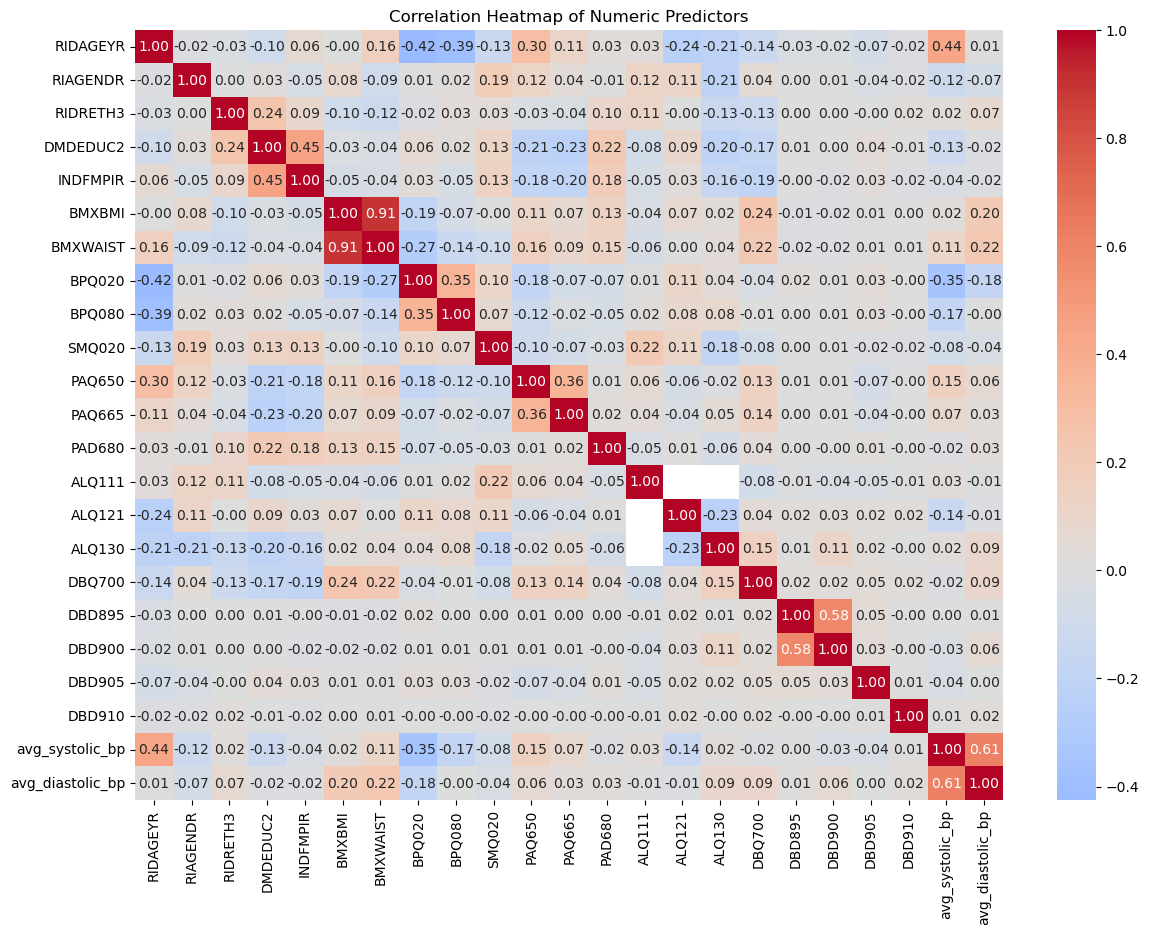

In [16]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Heatmap of Numeric Predictors")
plt.show()

In [17]:
# highly correlated pairs

corr_threshold = 0.85
corr_abs = corr_matrix.abs()

upper_triangle = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)
high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)
high_corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
high_corr_pairs = high_corr_pairs[
    high_corr_pairs["correlation"] > corr_threshold
].sort_values("correlation", ascending=False)

high_corr_pairs

,feature_1,feature_2,correlation
100,BMXBMI,BMXWAIST,0.905054


The correlation analysis identified a high positive correlation between BMXBMI and BMXWAIST. This indicates that BMI and waist circumference contain overlapping body-size information. However, both variables were retained because they have different clinical interpretations. BMI represents general body mass relative to height, while waist circumference captures abdominal obesity, which is an important diabetes-related risk factor.

Therefore, although these variables are highly correlated, they were not removed automatically. The decision to keep both was based on domain knowledge and their clinical relevance to diabetes risk screening.

In [18]:
# Use only numeric columns
X_numeric = X_pred2.select_dtypes(include=["int64", "float64"]).copy()

# Remove columns with all missing values, if any
X_numeric = X_numeric.dropna(axis=1, how="all")

# Impute missing values using median before VIF
imputer = SimpleImputer(strategy="median")
X_numeric_imputed = pd.DataFrame(
    imputer.fit_transform(X_numeric),
    columns=X_numeric.columns
)

vif_data = pd.DataFrame()
vif_data["feature"] = X_numeric_imputed.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_numeric_imputed.values, i)
    for i in range(X_numeric_imputed.shape[1])
]
vif_data = vif_data.sort_values("VIF", ascending=False)
vif_data

,feature,VIF
6,BMXWAIST,164.873451
21,avg_systolic_bp,104.381364
22,avg_diastolic_bp,96.518418
5,BMXBMI,78.257329
10,PAQ650,23.891526
0,RIDAGEYR,17.780308
13,ALQ111,17.512910
8,BPQ080,15.021846
7,BPQ020,13.760644
11,PAQ665,13.673178


The VIF table shows that several predictors have high multicollinearity, such as BMI, waist circumference, average systolic blood pressure, average diastolic blood pressure, etc. This is expected because these variables measure related clinical characteristics. These features were not removed automatically because they have defensible clinical connections to diabetes risk. However, high VIF values indicate that Logistic Regression coefficients should be interpreted carefully. Tree-based models such as Random Forest and XGBoost are less sensitive to multicollinearity.

In [19]:
# Model-based diagnostics: feature importance
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

In [20]:
# Make copy predictor and target
X = X_pred2.copy()
y = y_target.copy()

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (9232, 23)
Target shape: (9232,)


In [21]:
# Separate numeric and categorical columns

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

# In the NHANES data, some categorical variables are coded as numbers. 
# So manually move these coded categorical variables into categorical_features.

coded_categorical_features = [
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "BPQ020",
    "BPQ080",
    "SMQ020",
    "PAQ650",
    "PAQ665",
    "ALQ111",
    "ALQ121",
    "DBQ700"
]
coded_categorical_features = [
    col for col in coded_categorical_features if col in X.columns
]

# Remove coded categorical variables from numeric_features
numeric_features = [
    col for col in numeric_features if col not in coded_categorical_features
]

# Add coded categorical variables to categorical_features
categorical_features = list(set(categorical_features + coded_categorical_features))

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['RIDAGEYR', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'PAD680', 'ALQ130', 'DBD895', 'DBD900', 'DBD905', 'DBD910', 'avg_systolic_bp', 'avg_diastolic_bp']

Categorical features:
['DBQ700', 'SMQ020', 'PAQ665', 'ALQ121', 'RIAGENDR', 'DMDEDUC2', 'BPQ080', 'BPQ020', 'ALQ111', 'RIDRETH3', 'PAQ650']


In [22]:
# Preprocessing for numeric and categorical variables

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [23]:
# Random Forest model for feature importance

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

rf_pipeline.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
# Get feature names after preprocessing

# Numeric feature names
num_feature_names = numeric_features

# Categorical one-hot feature names
cat_encoder = rf_pipeline.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["onehot"]

cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()

# Combine all transformed feature names
all_feature_names = num_feature_names + cat_feature_names

print("Number of transformed features:", len(all_feature_names))

Number of transformed features: 53


In [25]:
# Extract feature importances

importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance_table = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_table.head(20)

,feature,importance
0,RIDAGEYR,0.129297
3,BMXWAIST,0.087871
2,BMXBMI,0.073514
10,avg_systolic_bp,0.059102
11,avg_diastolic_bp,0.056470
1,INDFMPIR,0.052799
4,PAD680,0.043644
42,BPQ020_2.0,0.036882
6,DBD895,0.035838
41,BPQ020_1.0,0.034211


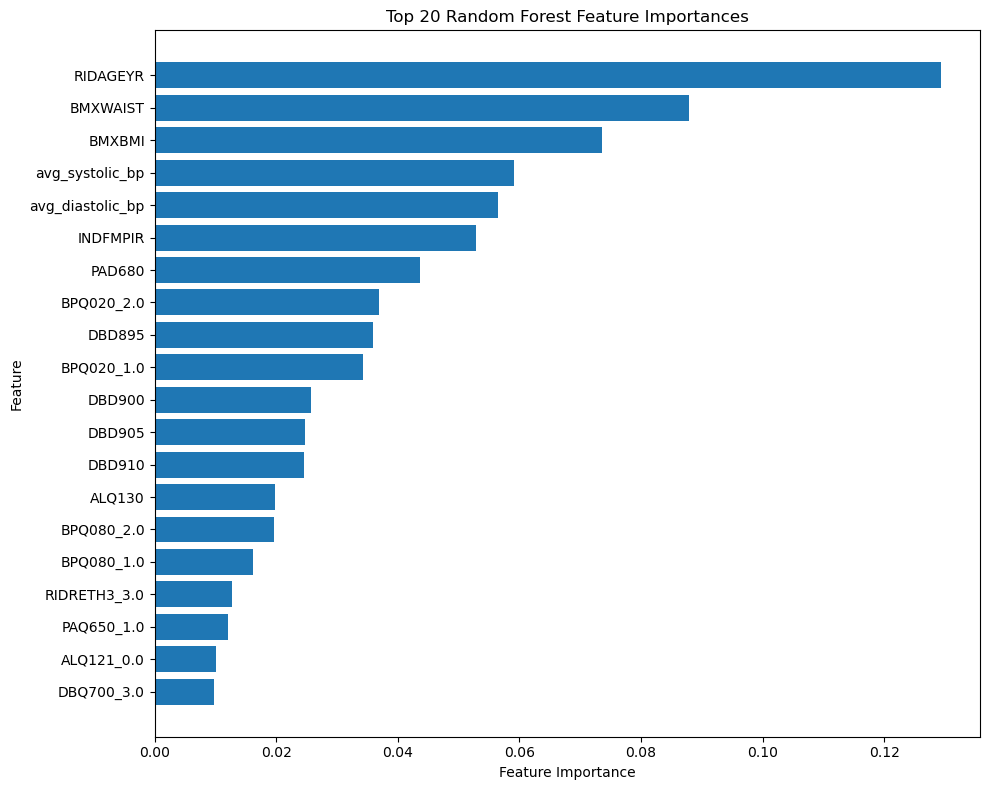

In [26]:
# Plot top 20 feature importances
top_n = 20
top_features = feature_importance_table.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [27]:
# Group one-hot encoded feature importances back to original variables

grouped_importance = []

for original_feature in X.columns:
    matching_rows = feature_importance_table[
        feature_importance_table["feature"].str.startswith(original_feature + "_")
        | (feature_importance_table["feature"] == original_feature)
    ]
    
    grouped_importance.append({
        "original_feature": original_feature,
        "total_importance": matching_rows["importance"].sum()
    })

grouped_importance_table = pd.DataFrame(grouped_importance)

grouped_importance_table = grouped_importance_table.sort_values(
    "total_importance",
    ascending=False
)

grouped_importance_table

,original_feature,total_importance
0,RIDAGEYR,0.129297
6,BMXWAIST,0.087871
5,BMXBMI,0.073514
7,BPQ020,0.071093
21,avg_systolic_bp,0.059102
22,avg_diastolic_bp,0.056470
14,ALQ121,0.052977
4,INDFMPIR,0.052799
2,RIDRETH3,0.045330
12,PAD680,0.043644


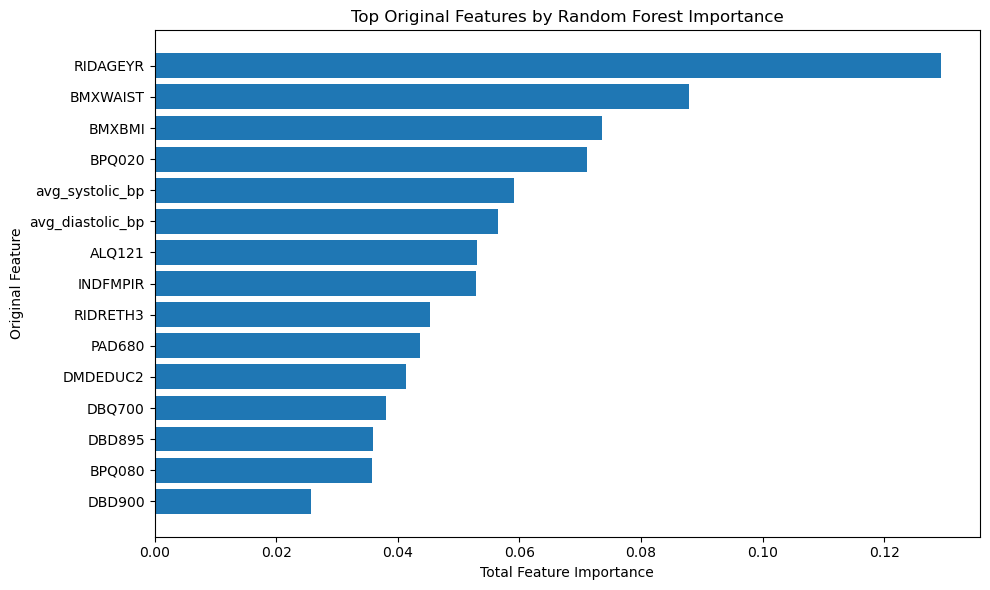

In [28]:
# Plot top original features by grouped importance

top_grouped = grouped_importance_table.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_grouped["original_feature"], top_grouped["total_importance"])
plt.gca().invert_yaxis()
plt.title("Top Original Features by Random Forest Importance")
plt.xlabel("Total Feature Importance")
plt.ylabel("Original Feature")
plt.tight_layout()
plt.show()

The Random Forest feature importance results showed which predictors were used most strongly by the model. Features such as age, BMI, waist circumference, blood pressure-related variables, and lifestyle or demographic variables were reviewed in relation to diabetes risk. These findings supported the overall feature selection process because many of the important variables were clinically meaningful and consistent with diabetes-related domain knowledge.

However, features were not removed only because they had low importance scores. Some variables may still be useful for interpretation, subgroup analysis, or other models. Therefore, model-based diagnostics were treated as a secondary check rather than the primary rule for selecting or dropping features. Final feature decisions were guided mainly by domain knowledge, leakage prevention, missingness, and redundancy checks.

In [29]:
X_pred_selected = X_pred2.copy()
print("After feature selection predictor shape:", X_pred_selected.shape)
X_pred_selected.head()

After feature selection predictor shape: (9232, 23)


,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,BPQ020,BPQ080,SMQ020,...,ALQ111,ALQ121,ALQ130,DBQ700,DBD895,DBD900,DBD905,DBD910,avg_systolic_bp,avg_diastolic_bp
0,29.0,2.0,6.0,5.0,5.00,37.8,117.9,2.0,1.0,2.0,...,1.0,10.0,1.0,3.0,7.0,0.0,0.0,5.0,99.000000,54.333333
1,21.0,2.0,2.0,4.0,5.00,NaN,NaN,2.0,2.0,2.0,...,NaN,NaN,NaN,1.0,4.0,0.0,0.0,0.0,NaN,NaN
2,49.0,1.0,3.0,2.0,NaN,29.7,120.4,2.0,1.0,1.0,...,1.0,0.0,NaN,3.0,2.0,2.0,0.0,0.0,107.000000,67.000000
3,36.0,1.0,3.0,4.0,0.83,21.9,86.8,2.0,2.0,1.0,...,1.0,0.0,NaN,4.0,2.0,2.0,0.0,7.0,113.666667,67.333333
4,68.0,1.0,7.0,4.0,1.20,30.2,109.6,1.0,1.0,2.0,...,1.0,4.0,2.0,2.0,0.0,NaN,0.0,0.0,134.000000,70.000000


In [30]:
y_target_selected = y_target.copy()

In [31]:
# Save selected predictors and target separately
processed_dir = Path("D:\Erdos\Data Science Bootcamp\summer26-diabetes-risk\early_diabetes_screening\data\processed")
X_pred_selected.to_csv(
    processed_dir / "X_pred_selected.csv",
    index=False
)
y_target_selected.to_csv(processed_dir / "y_target_selected.csv", index = False)

## Dropped Features with Justification

The following features were removed from the predictor set during feature selection. Features were dropped mainly for three reasons: target leakage, low information due to high missingness, and redundancy.

| Feature | Decision | Justification |
|---|---|---|
| `SEQN` | Dropped | Participant ID; not a meaningful predictor for diabetes risk |
| `diabetes` | Dropped | Target variable; should not be included as a predictor |
| `doctor_diabetes` | Dropped | Derived from `DIQ010`; directly related to the target |
| `DIQ010` | Dropped | Self-reported diabetes diagnosis; target leakage |
| `LBXGH` | Dropped | HbA1c value used to define the diabetes target; target leakage |
| `LBXGLU` | Dropped | Fasting glucose value used to define the diabetes target; target leakage |
| `PAD660` | Dropped | High missingness; detailed physical activity duration variable |
| `PAD675` | Dropped | High missingness; detailed physical activity duration variable |
| `PAQ655` | Dropped | High missingness; detailed physical activity variable |
| `PAQ670` | Dropped | High missingness; detailed physical activity variable |
| `BPXOSY1` | Replaced | Repeated systolic blood pressure reading; replaced by `avg_systolic_bp` |
| `BPXOSY2` | Replaced | Repeated systolic blood pressure reading; replaced by `avg_systolic_bp` |
| `BPXOSY3` | Replaced | Repeated systolic blood pressure reading; replaced by `avg_systolic_bp` |
| `BPXODI1` | Replaced | Repeated diastolic blood pressure reading; replaced by `avg_diastolic_bp` |
| `BPXODI2` | Replaced | Repeated diastolic blood pressure reading; replaced by `avg_diastolic_bp` |
| `BPXODI3` | Replaced | Repeated diastolic blood pressure reading; replaced by `avg_diastolic_bp` |

### Summary

Target leakage variables were removed because they either directly define the diabetes outcome or were created from variables used to define the outcome. High-missingness physical activity variables were removed because they contained limited usable information. Repeated blood pressure readings were not completely discarded; instead, they were summarized into average systolic and average diastolic blood pressure features to reduce redundancy while preserving clinically meaningful information.